# F4_02_Visualizaciones_Finales

Notebook para construir las visualizaciones finales de Fase 4.

Genera cuatro figuras:
1. Evolución anual de membresías por cada 100.000 habitantes.
2. Penetración promedio de gimnasios por región.
3. Relación entre PIB per cápita y participación fitness.
4. Comparación de indicadores por periodo.

Las figuras se guardan en `reports/fase4/figures/`.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

def encontrar_raiz_proyecto(nombre_repo="gym-fitness-analytics"):
    ruta_actual = Path.cwd().resolve()
    for ruta in [ruta_actual] + list(ruta_actual.parents):
        if ruta.name == nombre_repo:
            return ruta
    raise FileNotFoundError(f"No se pudo encontrar la raíz del proyecto '{nombre_repo}' desde {ruta_actual}")

PROJECT_ROOT = encontrar_raiz_proyecto()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "gym_data_processed.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset procesado en la ruta: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Dataset cargado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
df.head()

import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "reports" / "fase4" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

columnas_visualizacion = [
    "country", "region", "year", "memberships_per_100k",
    "gym_penetration_rate", "fitness_participation_rate",
    "gdp_per_capita_usd", "periodo"
]
faltantes = [col for col in columnas_visualizacion if col not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas para visualización: {faltantes}")
print("Columnas necesarias para visualización disponibles.")

Dataset cargado correctamente.
Filas: 3564
Columnas: 27
Columnas necesarias para visualización disponibles.


## Figura 1: evolución anual de membresías

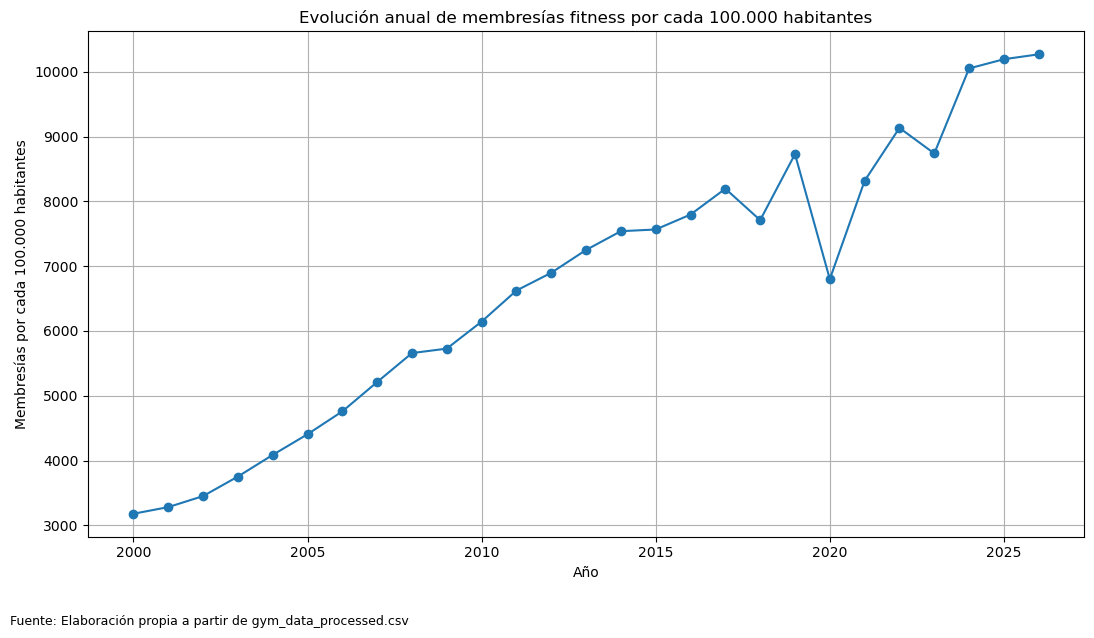

Figura guardada en: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\reports\fase4\figures\figura_1_evolucion_membresias.png


In [2]:
df_evolucion = (
    df.groupby("year")["memberships_per_100k"]
    .mean()
    .reset_index()
    .sort_values("year")
)

plt.figure(figsize=(11, 6))
plt.plot(df_evolucion["year"], df_evolucion["memberships_per_100k"], marker="o")
plt.title("Evolución anual de membresías fitness por cada 100.000 habitantes")
plt.xlabel("Año")
plt.ylabel("Membresías por cada 100.000 habitantes")
plt.grid(True)
plt.figtext(0.01, -0.05, "Fuente: Elaboración propia a partir de gym_data_processed.csv", ha="left", fontsize=9)
plt.tight_layout()
ruta_figura_1 = FIGURES_DIR / "figura_1_evolucion_membresias.png"
plt.savefig(ruta_figura_1, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", ruta_figura_1)

**Interpretación.** La evolución temporal de `memberships_per_100k` permite identificar tendencias generales de adopción de servicios fitness ajustadas por población. Esto permite comparar años con tamaños poblacionales distintos.

## Figura 2: penetración promedio de gimnasios por región

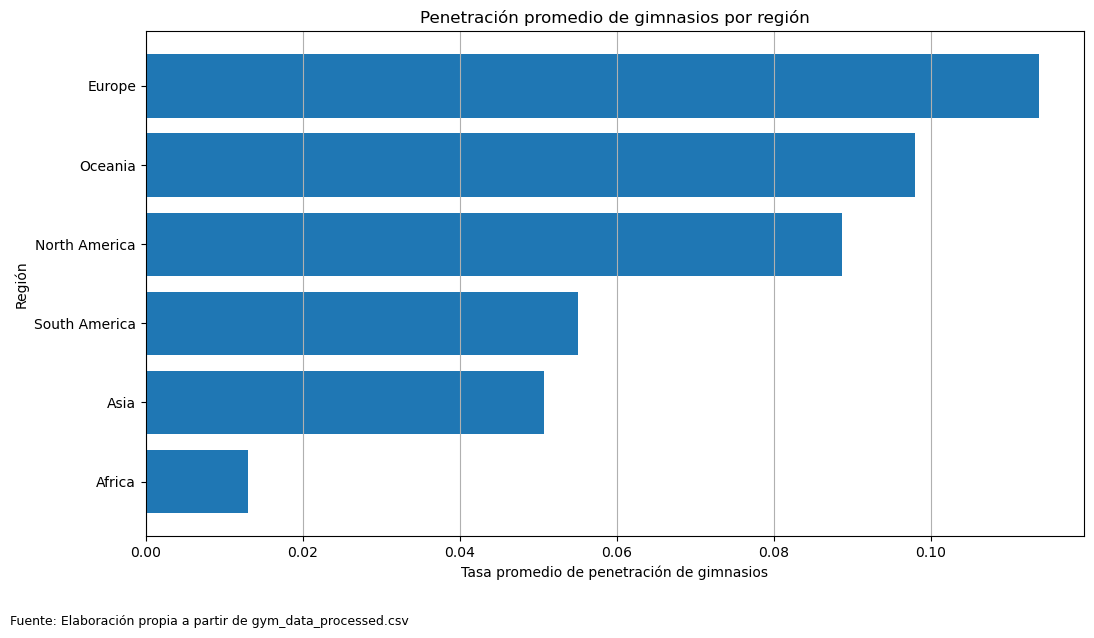

Figura guardada en: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\reports\fase4\figures\figura_2_penetracion_region.png


In [3]:
df_region = (
    df.groupby("region")["gym_penetration_rate"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

plt.figure(figsize=(11, 6))
plt.barh(df_region["region"], df_region["gym_penetration_rate"])
plt.title("Penetración promedio de gimnasios por región")
plt.xlabel("Tasa promedio de penetración de gimnasios")
plt.ylabel("Región")
plt.grid(axis="x")
plt.figtext(0.01, -0.05, "Fuente: Elaboración propia a partir de gym_data_processed.csv", ha="left", fontsize=9)
plt.tight_layout()
ruta_figura_2 = FIGURES_DIR / "figura_2_penetracion_region.png"
plt.savefig(ruta_figura_2, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", ruta_figura_2)

**Interpretación.** La comparación regional evidencia diferencias estructurales en la penetración de gimnasios. Estas diferencias pueden estar asociadas a infraestructura, ingreso, urbanización y madurez de mercado.

## Figura 3: PIB per cápita vs participación fitness

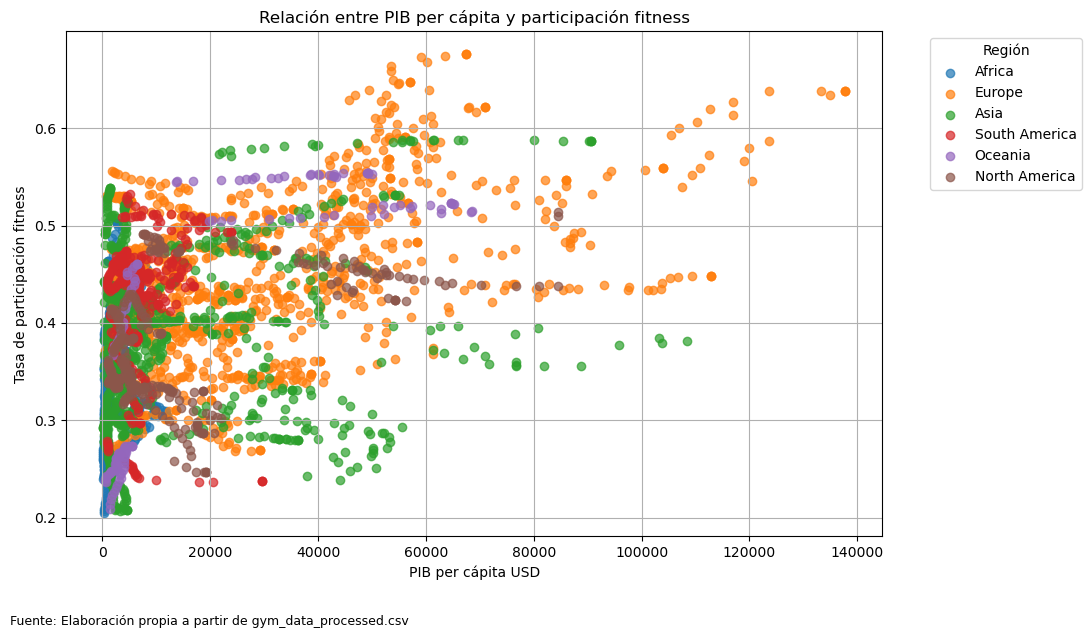

Figura guardada en: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\reports\fase4\figures\figura_3_pib_participacion.png


In [4]:
df_dispersion = df[["gdp_per_capita_usd", "fitness_participation_rate", "region"]].dropna().copy()

plt.figure(figsize=(11, 6))
for region in df_dispersion["region"].unique():
    datos_region = df_dispersion[df_dispersion["region"] == region]
    plt.scatter(
        datos_region["gdp_per_capita_usd"],
        datos_region["fitness_participation_rate"],
        label=region,
        alpha=0.7
    )
plt.title("Relación entre PIB per cápita y participación fitness")
plt.xlabel("PIB per cápita USD")
plt.ylabel("Tasa de participación fitness")
plt.legend(title="Región", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.figtext(0.01, -0.05, "Fuente: Elaboración propia a partir de gym_data_processed.csv", ha="left", fontsize=9)
plt.tight_layout()
ruta_figura_3 = FIGURES_DIR / "figura_3_pib_participacion.png"
plt.savefig(ruta_figura_3, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", ruta_figura_3)

**Interpretación.** Esta figura permite explorar si los países con mayor PIB per cápita tienden a presentar mayores niveles de participación fitness. La distinción por región permite identificar patrones geográficos.

## Figura 4: comparación por periodo

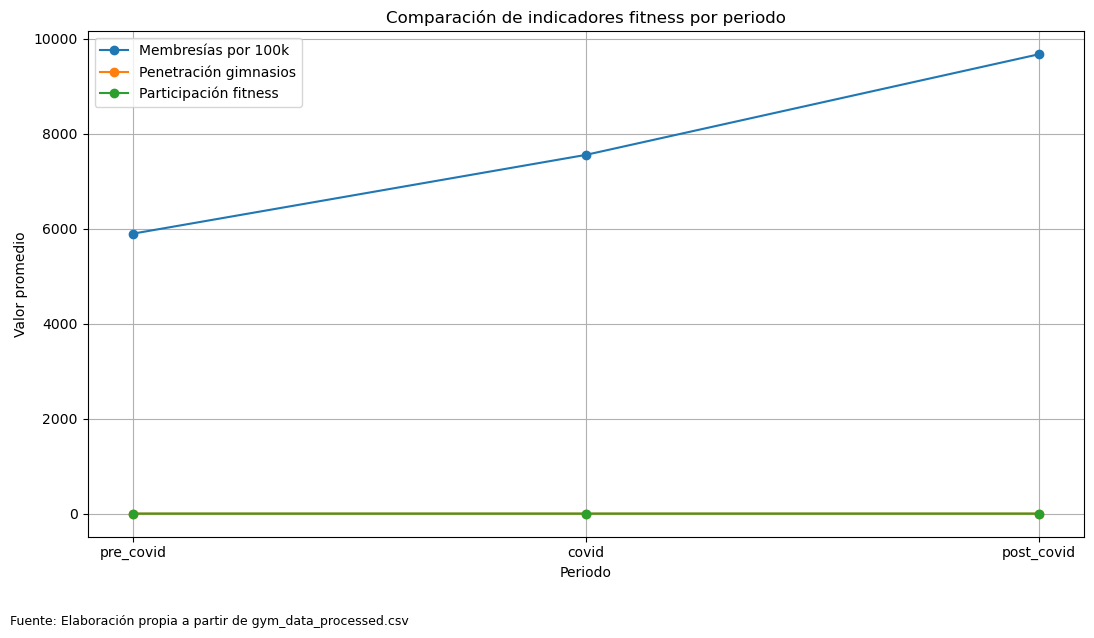

Figura guardada en: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\reports\fase4\figures\figura_4_comparacion_periodo.png


In [5]:
df_periodo = (
    df.groupby("periodo")[["memberships_per_100k", "gym_penetration_rate", "fitness_participation_rate"]]
    .mean()
    .reset_index()
)

orden_periodos = ["pre_covid", "covid", "post_covid"]
df_periodo["periodo"] = pd.Categorical(df_periodo["periodo"], categories=orden_periodos, ordered=True)
df_periodo = df_periodo.sort_values("periodo")

plt.figure(figsize=(11, 6))
plt.plot(df_periodo["periodo"], df_periodo["memberships_per_100k"], marker="o", label="Membresías por 100k")
plt.plot(df_periodo["periodo"], df_periodo["gym_penetration_rate"], marker="o", label="Penetración gimnasios")
plt.plot(df_periodo["periodo"], df_periodo["fitness_participation_rate"], marker="o", label="Participación fitness")
plt.title("Comparación de indicadores fitness por periodo")
plt.xlabel("Periodo")
plt.ylabel("Valor promedio")
plt.legend()
plt.grid(True)
plt.figtext(0.01, -0.05, "Fuente: Elaboración propia a partir de gym_data_processed.csv", ha="left", fontsize=9)
plt.tight_layout()
ruta_figura_4 = FIGURES_DIR / "figura_4_comparacion_periodo.png"
plt.savefig(ruta_figura_4, dpi=300, bbox_inches="tight")
plt.show()
print("Figura guardada en:", ruta_figura_4)

**Interpretación.** La segmentación por periodo permite observar cambios entre etapas pre COVID, COVID y post COVID, aportando contexto temporal para interpretar la evolución de los indicadores principales.

## Resumen de figuras generadas

In [6]:
df_figuras = pd.DataFrame([
    {"figura":"figura_1_evolucion_membresias.png", "objetivo":"Analizar tendencia temporal de membresías por población.", "ruta": str(FIGURES_DIR / "figura_1_evolucion_membresias.png")},
    {"figura":"figura_2_penetracion_region.png", "objetivo":"Comparar penetración de gimnasios entre regiones.", "ruta": str(FIGURES_DIR / "figura_2_penetracion_region.png")},
    {"figura":"figura_3_pib_participacion.png", "objetivo":"Explorar relación entre PIB per cápita y participación fitness.", "ruta": str(FIGURES_DIR / "figura_3_pib_participacion.png")},
    {"figura":"figura_4_comparacion_periodo.png", "objetivo":"Comparar indicadores fitness por periodo temporal.", "ruta": str(FIGURES_DIR / "figura_4_comparacion_periodo.png")}
])
df_figuras

,figura,objetivo,ruta
0,figura_1_evolucion_membresias.png,Analizar tendencia temporal de membresías por ...,C:\Users\warevalo\Documents\GitHub\gym-fitness...
1,figura_2_penetracion_region.png,Comparar penetración de gimnasios entre regiones.,C:\Users\warevalo\Documents\GitHub\gym-fitness...
2,figura_3_pib_participacion.png,Explorar relación entre PIB per cápita y parti...,C:\Users\warevalo\Documents\GitHub\gym-fitness...
3,figura_4_comparacion_periodo.png,Comparar indicadores fitness por periodo tempo...,C:\Users\warevalo\Documents\GitHub\gym-fitness...
